In [1]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: vicensyahsiagian
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:04<00:00, 164MB/s]


In [2]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device Available: ", device)

Device Available:  cuda


In [3]:
image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)

data_df = pd.DataFrame(zip(image_path, labels), columns=["image_path", "labels"])
print(data_df["labels"].unique())
print(f"Total data: {len(data_df)}")
data_df.head()

['wild' 'cat' 'dog']
Total data: 16130


,image_path,labels
0,/content/animal-faces/afhq/train/wild/flickr_w...,wild
1,/content/animal-faces/afhq/train/wild/flickr_w...,wild
2,/content/animal-faces/afhq/train/wild/flickr_w...,wild
3,/content/animal-faces/afhq/train/wild/flickr_w...,wild
4,/content/animal-faces/afhq/train/wild/flickr_w...,wild


In [4]:
train = data_df.sample(frac=0.6, random_state=42)
temp  = data_df.drop(train.index)
val   = temp.sample(frac=0.5, random_state=42)
test  = temp.drop(val.index)

print(f"Train: {train.shape[0]} | Val: {val.shape[0]} | Test: {test.shape[0]}")
print(f"Rasio Train: {train.shape[0]/len(data_df):.0%} | Val: {val.shape[0]/len(data_df):.0%} | Test: {test.shape[0]/len(data_df):.0%}")

Train: 9678 | Val: 3226 | Test: 3226
Rasio Train: 60% | Val: 20% | Test: 20%


In [5]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2,
                           contrast=0.2,
                           saturation=0.2),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

val_test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

In [6]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform=None):
    self.dataframe = dataframe.reset_index(drop=True)
    self.transform = transform
    self.labels = torch.tensor(
        label_encoder.transform(dataframe["labels"].values)
    ).to(device)

  def __len__(self):
    return len(self.dataframe)

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]
    image = Image.open(img_path).convert("RGB")
    if self.transform:
      image = self.transform(image).to(device)
    return image, label

train_dataset = CustomImageDataset(dataframe=train, transform=train_transform)
val_dataset   = CustomImageDataset(dataframe=val,   transform=val_test_transform)
test_dataset  = CustomImageDataset(dataframe=test,  transform=val_test_transform)

In [7]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3,   32,  kernel_size=3, padding=1)
    self.bn1   = nn.BatchNorm2d(32)

    self.conv2 = nn.Conv2d(32,  64,  kernel_size=3, padding=1)
    self.bn2   = nn.BatchNorm2d(64)

    self.conv3 = nn.Conv2d(64,  128, kernel_size=3, padding=1)
    self.bn3   = nn.BatchNorm2d(128)

    self.pooling = nn.MaxPool2d(2, 2)
    self.relu    = nn.ReLU()
    self.dropout = nn.Dropout(p=0.4)

    self.flatten = nn.Flatten()
    self.linear  = nn.Linear(128 * 16 * 16, 256)
    self.bn_fc   = nn.BatchNorm1d(256)
    self.output  = nn.Linear(256, len(data_df["labels"].unique()))

  def forward(self, x):
    x = self.relu(self.bn1(self.conv1(x)))
    x = self.pooling(x)

    x = self.relu(self.bn2(self.conv2(x)))
    x = self.pooling(x)

    x = self.relu(self.bn3(self.conv3(x)))
    x = self.pooling(x)

    x = self.flatten(x)
    x = self.dropout(self.relu(self.bn_fc(self.linear(x))))
    return self.output(x)

model = Net().to(device)
print(model)

Net(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (dropout): Dropout(p=0.4, inplace=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear): Linear(in_features=32768, out_features=256, bias=True)
  (bn_fc): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (output): Linear(in_features=256, out_features=3, bias=True)
)


In [8]:
LR         = 5e-4
BATCH_SIZE = 32     # dinaikkan dari 16
EPOCHS     = 20     # ditambah
PATIENCE   = 5

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

criterion = nn.CrossEntropyLoss()

optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3
)

In [9]:
total_loss_train_plot = []
total_loss_val_plot   = []
total_acc_train_plot  = []
total_acc_val_plot    = []

best_val_loss     = float("inf")
patience_counter  = 0

for epoch in range(EPOCHS):
    # ---- Training ----
    model.train()
    total_loss_train = 0
    total_acc_train  = 0

    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs    = model(inputs)
        loss       = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss_train += loss.item()
        total_acc_train  += (torch.argmax(outputs, dim=1) == labels).sum().item()

    model.eval()
    total_loss_val = 0
    total_acc_val  = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            total_loss_val += loss.item()
            total_acc_val  += (torch.argmax(outputs, dim=1) == labels).sum().item()

    avg_train_loss = total_loss_train / len(train_loader)
    avg_val_loss   = total_loss_val   / len(val_loader)
    train_acc      = total_acc_train  / len(train_dataset) * 100
    val_acc        = total_acc_val    / len(val_dataset)   * 100

    total_loss_train_plot.append(round(avg_train_loss, 4))
    total_loss_val_plot.append(round(avg_val_loss, 4))
    total_acc_train_plot.append(round(train_acc, 4))
    total_acc_val_plot.append(round(val_acc, 4))

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"Gap Acc: {abs(train_acc - val_acc):.2f}%")

    scheduler.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss    = avg_val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pt")  # simpan model terbaik
        print(f"  -> Model terbaik disimpan (val_loss: {best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  -> Patience: {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print(f"Early Stopping! Training dihentikan di epoch {epoch+1}")
            break

model.load_state_dict(torch.load("best_model.pt"))
print("\nModel terbaik dimuat untuk evaluasi.")


Epoch 1/20 | Train Loss: 0.3615 | Train Acc: 85.98% | Val Loss: 0.1585 | Val Acc: 94.30% | Gap Acc: 8.32%
  -> Model terbaik disimpan (val_loss: 0.1585)
Epoch 2/20 | Train Loss: 0.1688 | Train Acc: 93.83% | Val Loss: 0.0804 | Val Acc: 97.33% | Gap Acc: 3.50%
  -> Model terbaik disimpan (val_loss: 0.0804)
Epoch 3/20 | Train Loss: 0.1328 | Train Acc: 95.10% | Val Loss: 0.0884 | Val Acc: 96.87% | Gap Acc: 1.77%
  -> Patience: 1/5
Epoch 4/20 | Train Loss: 0.1125 | Train Acc: 95.84% | Val Loss: 0.1075 | Val Acc: 95.60% | Gap Acc: 0.24%
  -> Patience: 2/5
Epoch 5/20 | Train Loss: 0.0954 | Train Acc: 96.85% | Val Loss: 0.0644 | Val Acc: 97.61% | Gap Acc: 0.76%
  -> Model terbaik disimpan (val_loss: 0.0644)
Epoch 6/20 | Train Loss: 0.0931 | Train Acc: 96.52% | Val Loss: 0.0626 | Val Acc: 97.64% | Gap Acc: 1.13%
  -> Model terbaik disimpan (val_loss: 0.0626)
Epoch 7/20 | Train Loss: 0.0835 | Train Acc: 97.02% | Val Loss: 0.0604 | Val Acc: 97.58% | Gap Acc: 0.56%
  -> Model terbaik disimpan (val

In [10]:
# Evaluasi pada Test Set
model.eval()
total_loss_test = 0
total_acc_test  = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs         = model(inputs)
        loss            = criterion(outputs, labels)
        total_loss_test += loss.item()
        total_acc_test  += (torch.argmax(outputs, dim=1) == labels).sum().item()

test_acc  = total_acc_test / len(test_dataset) * 100
test_loss = total_loss_test / len(test_loader)
print(f"Test Accuracy: {test_acc:.2f}% | Test Loss: {test_loss:.4f}")

Test Accuracy: 99.04% | Test Loss: 0.0275


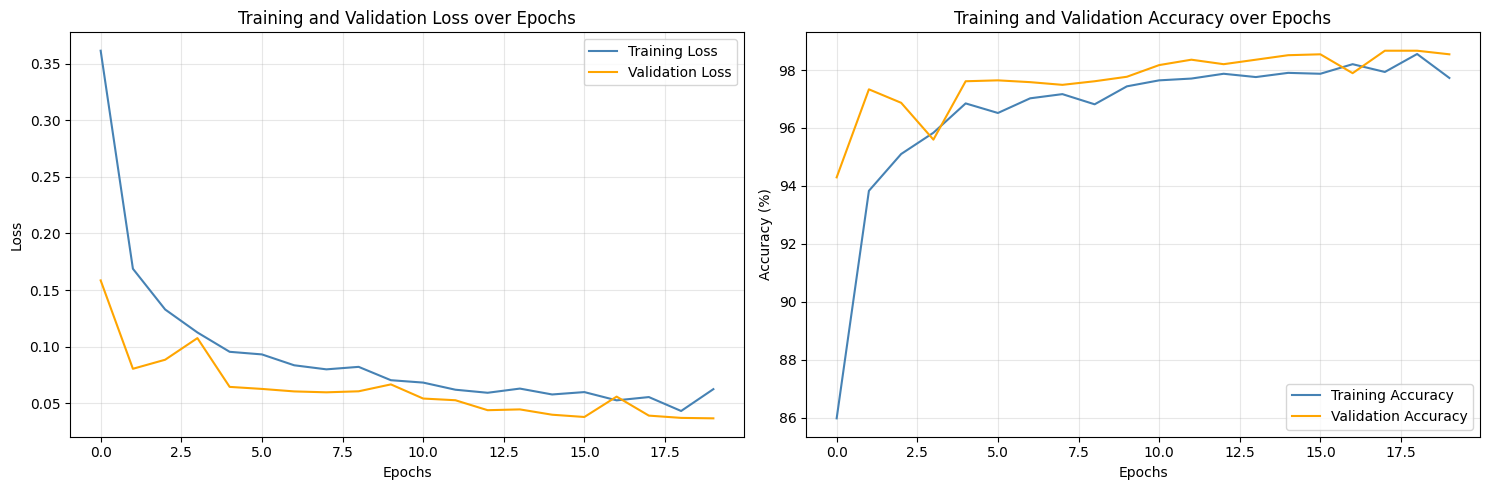


Gap akurasi akhir (train vs val): 0.82%
Status: GOOD FIT (gap < 5%)


In [11]:
# Visualisasi Hasil Training
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label="Training Loss",   color="steelblue")
axs[0].plot(total_loss_val_plot,   label="Validation Loss", color="orange")
axs[0].set_title("Training and Validation Loss over Epochs")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid(alpha=0.3)

axs[1].plot(total_acc_train_plot, label="Training Accuracy",   color="steelblue")
axs[1].plot(total_acc_val_plot,   label="Validation Accuracy", color="orange")
axs[1].set_title("Training and Validation Accuracy over Epochs")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy (%)")
axs[1].legend()
axs[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

if len(total_acc_train_plot) > 0:
    final_gap = abs(total_acc_train_plot[-1] - total_acc_val_plot[-1])
    print(f"\nGap akurasi akhir (train vs val): {final_gap:.2f}%")
    if final_gap < 5:
        print("Status: GOOD FIT (gap < 5%)")
    elif final_gap < 10:
        print("Status: Sedikit overfitting, masih acceptable")
    else:
        print("Status: OVERFITTING — perlu optimasi lebih lanjut")

In [15]:
def predict_image(image_path):
  model.eval()
  image  = Image.open(image_path).convert("RGB")
  image  = val_test_transform(image).to(device)
  output = model(image.unsqueeze(0))
  pred   = torch.argmax(output, dim=1).item()
  prob   = torch.softmax(output, dim=1).max().item()
  label  = label_encoder.inverse_transform([pred])[0]
  print(f"Prediksi: {label} (confidence: {prob*100:.1f}%)")
  return label

